# Loading Files

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd
menu_df=pd.read_csv(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\1_Data\Raw Data\Meghana_Master_Menu_Dataset.csv")

In [9]:
menu_df.head()

,Menu_ID,Dish_Name,Main_Category,Sub_Category,Bestseller,Price,Rating,Reviews,Calories,Protein_g,Carbs_g,Fat_g,Serves,Spice_Level
0,1,Aloo Dum Biryani,Veg,Biryani,Yes,330.0,4.5,1800+,1415.98,25.46,226.97,42.15,2,Moderate
1,2,Paneer Biryani,Veg,Biryani,Yes,380.0,4.6,6600+,1800.51,61.42,198.62,82.00,2,Slightly Spicy
2,3,Spl Veg Biryani,Veg,Biryani,Yes,340.0,4.6,2500+,1327.35,26.99,213.24,38.46,2,Slightly Spicy
3,4,Mushroom Biryani,Veg,Biryani,Yes,380.0,4.6,1900+,1225.80,29.42,186.92,37.51,2,Slightly Spicy
4,5,Veg Biryani Rice,Veg,Biryani,No,270.0,4.5,1500+,NaN,NaN,NaN,NaN,2,Spicy


In [10]:
print("Shape",menu_df.shape)
print("Columns",menu_df.columns)
print("First 5 records",menu_df.head())
print("Info of dataset",menu_df.info())


Shape (100, 14)
Columns Index(['Menu_ID', 'Dish_Name', 'Main_Category', 'Sub_Category', 'Bestseller',
       'Price', 'Rating', 'Reviews', 'Calories', 'Protein_g', 'Carbs_g',
       'Fat_g', 'Serves', 'Spice_Level'],
      dtype='object')
First 5 records    Menu_ID         Dish_Name Main_Category Sub_Category Bestseller  Price  \
0        1  Aloo Dum Biryani           Veg      Biryani        Yes  330.0   
1        2    Paneer Biryani           Veg      Biryani        Yes  380.0   
2        3   Spl Veg Biryani           Veg      Biryani        Yes  340.0   
3        4  Mushroom Biryani           Veg      Biryani        Yes  380.0   
4        5  Veg Biryani Rice           Veg      Biryani         No  270.0   

   Rating Reviews  Calories  Protein_g  Carbs_g  Fat_g  Serves     Spice_Level  
0     4.5   1800+   1415.98      25.46   226.97  42.15       2        Moderate  
1     4.6   6600+   1800.51      61.42   198.62  82.00       2  Slightly Spicy  
2     4.6   2500+   1327.35      26.99 

In [11]:
menu_df["Reviews_Clean"] = (
    menu_df["Reviews"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

menu_df["Reviews_Clean"] = pd.to_numeric(
    menu_df["Reviews_Clean"],
    errors="coerce"
)

menu_df["Rating"] = pd.to_numeric(
    menu_df["Rating"],
    errors="coerce"
)

menu_df.head()

,Menu_ID,Dish_Name,Main_Category,Sub_Category,Bestseller,Price,Rating,Reviews,Calories,Protein_g,Carbs_g,Fat_g,Serves,Spice_Level,Reviews_Clean
0,1,Aloo Dum Biryani,Veg,Biryani,Yes,330.0,4.5,1800+,1415.98,25.46,226.97,42.15,2,Moderate,1800.0
1,2,Paneer Biryani,Veg,Biryani,Yes,380.0,4.6,6600+,1800.51,61.42,198.62,82.00,2,Slightly Spicy,6600.0
2,3,Spl Veg Biryani,Veg,Biryani,Yes,340.0,4.6,2500+,1327.35,26.99,213.24,38.46,2,Slightly Spicy,2500.0
3,4,Mushroom Biryani,Veg,Biryani,Yes,380.0,4.6,1900+,1225.80,29.42,186.92,37.51,2,Slightly Spicy,1900.0
4,5,Veg Biryani Rice,Veg,Biryani,No,270.0,4.5,1500+,NaN,NaN,NaN,NaN,2,Spicy,1500.0


In [12]:
print("Rows:", menu_df.shape[0])
print("Columns:", menu_df.shape[1])
print("Missing Values:")
print(menu_df.isnull().sum())

Rows: 100
Columns: 15
Missing Values:
Menu_ID           0
Dish_Name         0
Main_Category     0
Sub_Category      0
Bestseller        0
Price             0
Rating            1
Reviews           1
Calories         57
Protein_g        57
Carbs_g          57
Fat_g            57
Serves            0
Spice_Level       4
Reviews_Clean     1
dtype: int64


# Menu KPI Dashboard

In [13]:
total_items = len(menu_df)

veg_items = len(menu_df[menu_df["Main_Category"]=="Veg"])

nonveg_items = len(menu_df[menu_df["Main_Category"]=="Non-Veg"])

bestseller_items = len(
    menu_df[
        menu_df["Bestseller"]
        .str.upper()
        .eq("YES")
    ]
)

avg_rating = round(
    menu_df["Rating"].mean(),
    2
)

avg_price = round(
    menu_df["Price"].mean(),
    2
)

menu_health_score = round(
    (avg_rating/5)*100,
    0
)

if menu_health_score >= 85:
    menu_health = "Excellent"
elif menu_health_score >= 70:
    menu_health = "Good"
else:
    menu_health = "Needs Improvement"

menu_kpi = pd.DataFrame({
    "Metric":[
        "Total Menu Items",
        "Veg Items",
        "Non-Veg Items",
        "Bestseller Items",
        "Average Rating",
        "Average Price",
        "Menu Health Score",
        "Overall Menu Health"
    ],
    "Value":[
        total_items,
        veg_items,
        nonveg_items,
        bestseller_items,
        avg_rating,
        avg_price,
        menu_health_score,
        menu_health
    ]
})

display(menu_kpi)

,Metric,Value
0,Total Menu Items,100
1,Veg Items,48
2,Non-Veg Items,52
3,Bestseller Items,10
4,Average Rating,4.45
5,Average Price,330.22
6,Menu Health Score,89.0
7,Overall Menu Health,Excellent


# Veg Vs Non Veg chart

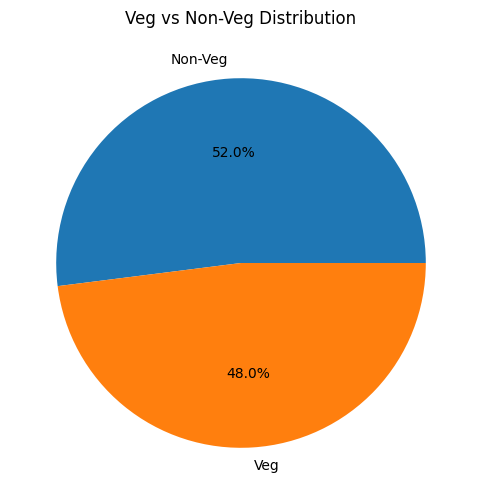

In [14]:
plt.figure(figsize=(6,6))

menu_df["Main_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Veg vs Non-Veg Distribution")

plt.ylabel("")

plt.show()

# category distribution

In [15]:
category_dist = (
    menu_df["Sub_Category"]
    .value_counts()
)

display(category_dist)

Sub_Category
Starter            31
Curry              22
Biryani            18
Box Biryani        13
Rice                6
Beverage            4
Seafood Starter     4
Bread               1
Egg                 1
Name: count, dtype: int64

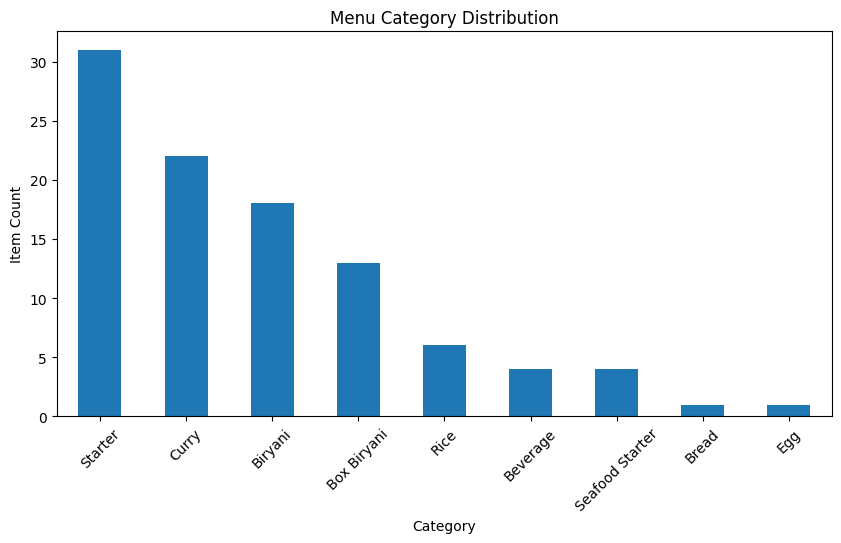

In [16]:
plt.figure(figsize=(10,5))

category_dist.plot(
    kind="bar"
)

plt.title("Menu Category Distribution")

plt.xlabel("Category")

plt.ylabel("Item Count")

plt.xticks(rotation=45)

plt.show()

# Rating Distribution

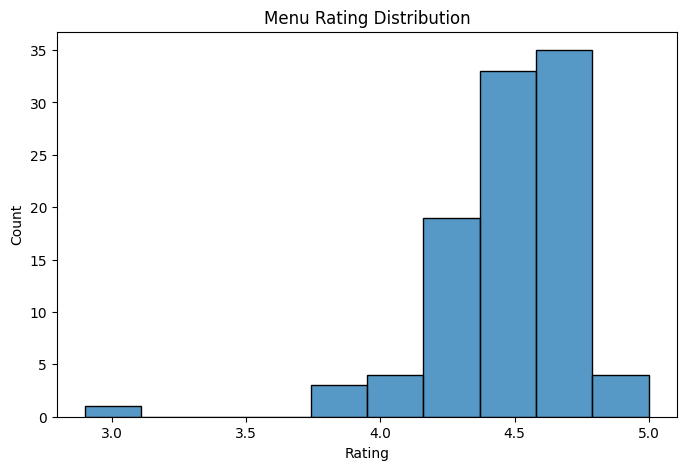

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    menu_df["Rating"],
    bins=10
)

plt.title("Menu Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

# Price Distribution

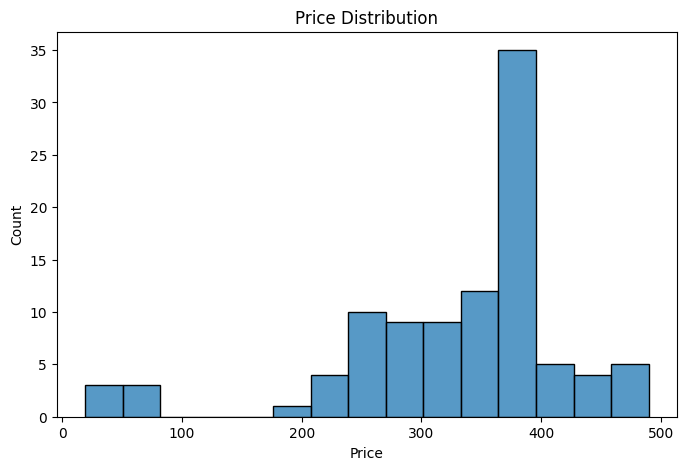

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    menu_df["Price"],
    bins=15
)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

# hereo products

In [20]:
hero_df = menu_df.copy()

hero_df["Rating_Score"] = hero_df["Rating"] * 20

hero_df["Review_Score"] = (
    hero_df["Reviews_Clean"]
    / hero_df["Reviews_Clean"].max()
) * 100

hero_df["Bestseller_Score"] = np.where(
    hero_df["Bestseller"]=="Yes",
    20,
    0
)

hero_df["Hero_Score"] = (
      hero_df["Rating_Score"]*0.4
    + hero_df["Review_Score"]*0.5
    + hero_df["Bestseller_Score"]*0.1
)

hero_products = (
    hero_df[
        [
            "Dish_Name",
            "Rating",
            "Reviews_Clean",
            "Bestseller",
            "Price",
            "Hero_Score"
        ]
    ]
    .sort_values(
        "Hero_Score",
        ascending=False
    )
)

hero_products.head(15)

,Dish_Name,Rating,Reviews_Clean,Bestseller,Price,Hero_Score
49,Chicken Boneless Biryani,4.6,12900.0,Yes,375.0,88.800000
1,Paneer Biryani,4.6,6600.0,Yes,380.0,64.381395
2,Spl Veg Biryani,4.6,2500.0,Yes,340.0,48.489922
48,Chicken Biryani,4.4,2600.0,Yes,365.0,47.277519
3,Mushroom Biryani,4.6,1900.0,Yes,380.0,46.164341
50,Meghana Special Boneless Biryani,4.6,1700.0,Yes,383.0,45.389147
0,Aloo Dum Biryani,4.5,1800.0,Yes,330.0,44.976744
89,Pepper Chicken,4.5,1700.0,Yes,370.0,44.589147
84,Meghana Chicken 555,4.5,1100.0,Yes,375.0,42.263566
83,Chicken 65,4.6,1300.0,No,375.0,41.838760


In [21]:
hero_df["Product_Type"] = np.select(
    [
        hero_df["Hero_Score"] >= 85,
        hero_df["Hero_Score"] >= 70,
        hero_df["Hero_Score"] >= 50
    ],
    [
        "Hero Product",
        "High Potential",
        "Hidden Gem"
    ],
    default="Underperforming"
)

In [22]:
hero_df

,Menu_ID,Dish_Name,Main_Category,Sub_Category,Bestseller,Price,Rating,Reviews,Calories,Protein_g,Carbs_g,Fat_g,Serves,Spice_Level,Reviews_Clean,Rating_Score,Review_Score,Bestseller_Score,Hero_Score,Product_Type
0,1,Aloo Dum Biryani,Veg,Biryani,Yes,330.0,4.5,1800+,1415.98,25.46,226.97,42.15,2,Moderate,1800.0,90.0,13.953488,20,44.976744,Underperforming
1,2,Paneer Biryani,Veg,Biryani,Yes,380.0,4.6,6600+,1800.51,61.42,198.62,82.00,2,Slightly Spicy,6600.0,92.0,51.162791,20,64.381395,Hidden Gem
2,3,Spl Veg Biryani,Veg,Biryani,Yes,340.0,4.6,2500+,1327.35,26.99,213.24,38.46,2,Slightly Spicy,2500.0,92.0,19.379845,20,48.489922,Underperforming
3,4,Mushroom Biryani,Veg,Biryani,Yes,380.0,4.6,1900+,1225.80,29.42,186.92,37.51,2,Slightly Spicy,1900.0,92.0,14.728682,20,46.164341,Underperforming
4,5,Veg Biryani Rice,Veg,Biryani,No,270.0,4.5,1500+,NaN,NaN,NaN,NaN,2,Spicy,1500.0,90.0,11.627907,0,41.813953,Underperforming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Chilly Fish,Non-Veg,Seafood Starter,No,390.0,4.4,91,NaN,NaN,NaN,NaN,1,Spicy,91.0,88.0,0.705426,0,35.552713,Underperforming
96,97,Apollo Fish,Non-Veg,Seafood Starter,No,395.0,4.6,190,NaN,NaN,NaN,NaN,1,Spicy,190.0,92.0,1.472868,0,37.536434,Underperforming
97,98,Chilli Prawns,Non-Veg,Seafood Starter,No,445.0,4.6,305,NaN,NaN,NaN,NaN,1,Spicy,305.0,92.0,2.364341,0,37.982171,Underperforming
98,99,Prawns Fry,Non-Veg,Seafood Starter,No,445.0,4.6,136,NaN,NaN,NaN,NaN,1,Moderate,136.0,92.0,1.054264,0,37.327132,Underperforming


# Top Rated

In [23]:
top_rated = (
    menu_df[
        ["Dish_Name",
         "Rating",
         "Reviews_Clean",
         "Price"]
    ]
    .query("Reviews_Clean >= 500")
    .sort_values(
        ["Rating","Reviews_Clean"],
        ascending=False
    )
)

top_rated.head(15)

,Dish_Name,Rating,Reviews_Clean,Price
49,Chicken Boneless Biryani,4.6,12900.0,375.0
1,Paneer Biryani,4.6,6600.0,380.0
2,Spl Veg Biryani,4.6,2500.0,340.0
3,Mushroom Biryani,4.6,1900.0,380.0
50,Meghana Special Boneless Biryani,4.6,1700.0,383.0
83,Chicken 65,4.6,1300.0,375.0
85,Lemon Chicken,4.6,901.0,375.0
70,Chicken Boneless Curry,4.6,885.0,370.0
54,Prawns Biryani,4.6,640.0,470.0
60,Box Chicken Boneless Biryani,4.6,621.0,265.0


# under performing dishes 

In [27]:
weak_df = menu_df.copy()

def classify_menu_item(row):

    rating = row["Rating"]
    reviews = row["Reviews_Clean"]

    if pd.isna(rating):
        return "Needs Review"

    # Poor performers
    if rating <= 3.8:
        return "Review or Replace"

    # Average performers
    elif rating <= 4.2:
        return "Monitor Performance"

    # Hidden opportunities
    elif rating <= 4.4:

        if reviews < 500:
            return "Hidden Item - Improve Visibility"

        else:
            return "Growth Item"

    # Strong performers
    else:

        if reviews >= 1000:
            return "Star Product"

        else:
            return "High Potential Product"


weak_df["Recommended_Menu_Action"] = weak_df.apply(
    classify_menu_item,
    axis=1
)

menu_cleanup_candidates = (
    weak_df[
        [
            "Dish_Name",
            "Rating",
            "Reviews_Clean",
            "Bestseller",
            "Price",
            "Recommended_Menu_Action"
        ]
    ]
    .sort_values(
        ["Rating", "Reviews_Clean"],
        ascending=[True, True]
    )
)

display(menu_cleanup_candidates.head(25))

,Dish_Name,Rating,Reviews_Clean,Bestseller,Price,Recommended_Menu_Action
93,Today's Andhra Spl,2.9,21.0,No,410.0,Review or Replace
74,Fish Curry,3.8,42.0,No,425.0,Review or Replace
25,Kaju Masala,3.8,101.0,No,380.0,Review or Replace
75,Prawns Curry,3.9,96.0,No,460.0,Monitor Performance
24,Veg Hyderabadi Curry,4.0,7.0,No,320.0,Monitor Performance
42,Mushroom Kabab,4.0,9.0,No,385.0,Monitor Performance
72,Chicken Curry,4.0,85.0,No,370.0,Monitor Performance
62,Box Chicken Fry Biryani,4.1,7.0,No,270.0,Monitor Performance
5,Veg Manchurian Biryani,4.2,734.0,No,370.0,Monitor Performance
79,Chicken Hyd Curry With Bone,4.3,10.0,No,370.0,Hidden Item - Improve Visibility


# combo intelligence

In [28]:
combo_candidates = (
    hero_products[
        [
            "Dish_Name",
            "Rating",
            "Reviews_Clean",
            "Price"
        ]
    ]
    .head(10)
)

combo_candidates

,Dish_Name,Rating,Reviews_Clean,Price
49,Chicken Boneless Biryani,4.6,12900.0,375.0
1,Paneer Biryani,4.6,6600.0,380.0
2,Spl Veg Biryani,4.6,2500.0,340.0
48,Chicken Biryani,4.4,2600.0,365.0
3,Mushroom Biryani,4.6,1900.0,380.0
50,Meghana Special Boneless Biryani,4.6,1700.0,383.0
0,Aloo Dum Biryani,4.5,1800.0,330.0
89,Pepper Chicken,4.5,1700.0,370.0
84,Meghana Chicken 555,4.5,1100.0,375.0
83,Chicken 65,4.6,1300.0,375.0


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

menu_df = pd.read_csv("Meghana_Master_Menu_Dataset.csv")

menu_df["Reviews_Clean"] = (
    menu_df["Reviews"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

menu_df["Reviews_Clean"] = pd.to_numeric(menu_df["Reviews_Clean"], errors="coerce")
menu_df["Rating"] = pd.to_numeric(menu_df["Rating"], errors="coerce")


def print_section(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)


def print_subsection(title):
    print("\n" + "-"*100)
    print(title)
    print("-"*100)


def format_rupees(value):
    return f"₹{value:,.0f}"


def classify_menu_item(row):
    rating = row["Rating"]
    reviews = row["Reviews_Clean"]

    if pd.isna(rating):
        return "Needs Review"

    if rating <= 3.8:
        return "Review or Replace"

    elif rating <= 4.2:
        return "Monitor Performance"

    elif rating <= 4.4:
        if reviews < 500:
            return "Hidden Item - Improve Visibility"
        else:
            return "Growth Item"

    else:
        if reviews >= 1000:
            return "Star Product"
        else:
            return "High Potential Product"


def menu_intelligence_report(menu_df):

    menu_df = menu_df.copy()

    menu_df["Recommended_Menu_Action"] = menu_df.apply(classify_menu_item, axis=1)

    total_items = len(menu_df)
    veg_items = len(menu_df[menu_df["Main_Category"] == "Veg"])
    nonveg_items = len(menu_df[menu_df["Main_Category"] == "Non-Veg"])

    bestseller_items = len(
        menu_df[menu_df["Bestseller"].str.upper() == "YES"]
    )

    avg_rating = round(menu_df["Rating"].mean(), 2)
    avg_price = round(menu_df["Price"].mean(), 2)

    menu_health_score = round((avg_rating / 5) * 100, 0)

    if menu_health_score >= 85:
        menu_health = "Excellent"
    elif menu_health_score >= 70:
        menu_health = "Good"
    else:
        menu_health = "Needs Improvement"

    print_section("MENU INTELLIGENCE REPORT")

    print("Executive Summary")
    print(f"Total Menu Items: {total_items}")
    print(f"Veg Items: {veg_items}")
    print(f"Non-Veg Items: {nonveg_items}")
    print(f"Bestseller Items: {bestseller_items}")
    print(f"Average Menu Rating: {avg_rating} / 5")
    print(f"Average Dish Price: {format_rupees(avg_price)}")
    print(f"Menu Health Score: {menu_health_score} / 100")
    print(f"Overall Menu Health: {menu_health}")

    print("\nAI Insight:")
    print(
        "The menu is already performing strongly. "
        "The objective is not to redesign the entire menu. "
        "The objective is to promote winning dishes, improve weak dishes, "
        "increase average order value, and improve visibility on online ordering platforms."
    )

    print_section("MENU PERFORMANCE DASHBOARD")

    print_subsection("Veg vs Non-Veg Distribution")
    display(menu_df["Main_Category"].value_counts())

    plt.figure(figsize=(6, 6))
    menu_df["Main_Category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title("Veg vs Non-Veg Distribution")
    plt.ylabel("")
    plt.show()

    print_subsection("Menu Category Distribution")
    category_dist = menu_df["Sub_Category"].value_counts()
    display(category_dist)

    plt.figure(figsize=(10, 5))
    category_dist.plot(kind="bar")
    plt.title("Menu Category Distribution")
    plt.xlabel("Category")
    plt.ylabel("Item Count")
    plt.xticks(rotation=45)
    plt.show()

    print_subsection("Average Rating by Category")
    category_rating = (
        menu_df.groupby("Sub_Category")["Rating"]
        .mean()
        .sort_values(ascending=False)
    )

    display(category_rating)

    plt.figure(figsize=(10, 5))
    category_rating.plot(kind="bar")
    plt.title("Average Rating by Menu Category")
    plt.xlabel("Category")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.show()

    print("\nAI Insight:")
    print(
        "The menu has a good balance between Veg and Non-Veg items. "
        "Starters, curries and biryani dominate the menu. "
        "However, customer demand is strongly connected to biryani products, "
        "so biryani should remain the main business engine."
    )

    print_section("BESTSELLER INTELLIGENCE")

    bestseller_df = (
        menu_df[menu_df["Bestseller"].str.upper() == "YES"]
        .sort_values(["Reviews_Clean", "Rating"], ascending=False)
        [
            [
                "Dish_Name",
                "Main_Category",
                "Sub_Category",
                "Rating",
                "Reviews_Clean",
                "Price"
            ]
        ]
    )

    display(bestseller_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=bestseller_df.head(10),
        x="Reviews_Clean",
        y="Dish_Name"
    )
    plt.title("Top Bestseller Items by Review Count")
    plt.xlabel("Reviews")
    plt.ylabel("Dish")
    plt.show()

    print("\nAI Insight:")
    print(
        "Bestseller items are already validated by customers. "
        "These products should receive the highest visibility on Swiggy, Zomato, "
        "Instagram promotions, combo offers and in-store recommendation boards."
    )

    print_section("HERO PRODUCT STRATEGY")

    hero_df = menu_df.copy()

    hero_df["Rating_Score"] = hero_df["Rating"] * 20

    hero_df["Review_Score"] = (
        hero_df["Reviews_Clean"] / hero_df["Reviews_Clean"].max()
    ) * 100

    hero_df["Bestseller_Score"] = np.where(
        hero_df["Bestseller"].str.upper() == "YES",
        20,
        0
    )

    hero_df["Hero_Score"] = (
        hero_df["Rating_Score"] * 0.4
        + hero_df["Review_Score"] * 0.5
        + hero_df["Bestseller_Score"] * 0.1
    )

    hero_products = (
        hero_df[
            [
                "Dish_Name",
                "Rating",
                "Reviews_Clean",
                "Bestseller",
                "Price",
                "Hero_Score"
            ]
        ]
        .sort_values("Hero_Score", ascending=False)
    )

    display(hero_products.head(10))

    hero_product = hero_products.iloc[0]["Dish_Name"]

    print("\nHero Product:")
    print(hero_product)

    print("\nWhy this is the hero product:")
    print(
        "This dish has the strongest combination of rating, review volume, "
        "customer validation and bestseller status. "
        "It should be treated as the flagship product of the menu."
    )

    print("\nAction Plan:")
    print("1. Pin this item as the first item on Swiggy.")
    print("2. Pin this item as the first item on Zomato.")
    print("3. Use this item in Instagram reels and YouTube Shorts.")
    print("4. Use this item in outdoor advertisements.")
    print("5. Position it as Meghana's signature dish.")

    print("\nExpected Impact:")
    print("Higher conversion rates, better customer acquisition, stronger brand recall.")

    print_section("MOST LOVED DISHES")

    most_loved = (
        menu_df[
            [
                "Dish_Name",
                "Rating",
                "Reviews_Clean",
                "Price"
            ]
        ]
        .query("Reviews_Clean >= 500")
        .sort_values(["Rating", "Reviews_Clean"], ascending=False)
        .head(15)
    )

    display(most_loved)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=most_loved.head(10),
        x="Reviews_Clean",
        y="Dish_Name"
    )
    plt.title("Most Loved Dishes with Strong Customer Validation")
    plt.xlabel("Reviews")
    plt.ylabel("Dish")
    plt.show()

    print("\nAI Recommendation:")
    print(
        "Create premium combos around these dishes. "
        "Never discount weak products heavily. "
        "Promote winning products because customers have already validated them."
    )

    print_section("UNDERPERFORMING MENU ANALYSIS")

    cleanup_candidates = (
        menu_df[
            [
                "Dish_Name",
                "Rating",
                "Reviews_Clean",
                "Bestseller",
                "Price",
                "Recommended_Menu_Action"
            ]
        ]
        .sort_values(["Rating", "Reviews_Clean"], ascending=[True, True])
    )

    display(cleanup_candidates.head(25))

    action_counts = menu_df["Recommended_Menu_Action"].value_counts()
    display(action_counts)

    plt.figure(figsize=(10, 5))
    action_counts.plot(kind="bar")
    plt.title("Menu Action Classification")
    plt.xlabel("Recommended Action")
    plt.ylabel("Item Count")
    plt.xticks(rotation=45)
    plt.show()

    print("\nAI Insight:")
    print(
        "The menu does not have a widespread quality issue. "
        "Most dishes are rated well. "
        "However, a few dishes need immediate review, while several hidden items need better visibility."
    )

    print_section("MENU CLEANUP STRATEGY")

    review_or_replace = menu_df[
        menu_df["Recommended_Menu_Action"] == "Review or Replace"
    ][["Dish_Name", "Rating", "Reviews_Clean", "Price"]]

    monitor_items = menu_df[
        menu_df["Recommended_Menu_Action"] == "Monitor Performance"
    ][["Dish_Name", "Rating", "Reviews_Clean", "Price"]]

    hidden_items = menu_df[
        menu_df["Recommended_Menu_Action"] == "Hidden Item - Improve Visibility"
    ][["Dish_Name", "Rating", "Reviews_Clean", "Price"]]

    print_subsection("Immediate Review or Replace List")
    display(review_or_replace)

    print("\nAction Plan:")
    print("Step 1: Collect customer feedback.")
    print("Step 2: Review recipe consistency.")
    print("Step 3: Compare with competitor dishes.")
    print("Step 4: Improve presentation.")
    print("Step 5: Retest for 30 days.")
    print("Step 6: Remove if ratings do not improve.")

    print_subsection("Monitor Performance Items")
    display(monitor_items.head(10))

    print("\nAction Plan:")
    print(
        "These dishes are not failures, but they are not strong enough for aggressive promotion. "
        "Monitor them for 60 days before deciding whether to improve, bundle, or reduce visibility."
    )

    print_subsection("Hidden Items - Improve Visibility")
    display(hidden_items.head(10))

    print("\nAction Plan:")
    print(
        "These dishes are not bad. They have decent ratings but low review volume. "
        "Place them in 'Recommended Add-ons', 'People Also Ordered', and combo sections "
        "on Swiggy and Zomato to increase visibility."
    )

    print_section("COMBO INTELLIGENCE")

    top_items = hero_products.head(10)

    display(top_items[["Dish_Name", "Rating", "Reviews_Clean", "Price"]])

    print_subsection("Family Feast Combo")
    print("Chicken Boneless Biryani + Chicken 65 + Soft Drink + Dessert")
    print("Target: Families, weekend customers, group orders")

    print_subsection("Veg Family Combo")
    print("Paneer Biryani + Chilly Paneer + Soft Drink + Dessert")
    print("Target: Vegetarian families and office groups")

    print_subsection("Office Lunch Combo")
    print("Box Chicken Boneless Biryani (or Introduce Bucket Biriyani) + Soft Drink")
    print("Target: IT employees, office workers, students")

    print_subsection("IPL Match Combo")
    print("Chicken Biryani (or Introduce Bucket Biriyani) + Chicken 65 + Soft Drink")
    print("Target: Friends watching cricket")

    print_subsection("Late Night Combo")
    print("Chicken Boneless Biryani (or Introduce Bucket Biriyani) + Pepper Chicken")
    print("Target: Students, night shift employees, late-night orders")

    print("\nAI Insight:")
    print(
        "Customers are already buying biryani. "
        "The goal is to increase the value of each order by bundling biryani with starters, drinks and desserts. "
        "This can increase average order value without needing new customers."
    )

    print_section("SWIGGY & ZOMATO GROWTH STRATEGY")

    print("Current Opportunity:")
    print(
        "Most customers discover and order food through delivery platforms. "
        "The strongest dishes should dominate app visibility."
    )

    print("\nPriority Actions:")
    print("1. Pin Chicken Boneless Biryani at the top.")
    print("2. Pin Paneer Biryani as the top vegetarian option.")
    print("3. Add labels like 'Most Ordered', 'Top Rated', and 'Customer Favourite'.")
    print("4. Create visible combo sections instead of listing only single dishes.")
    print("5. Run a ₹50 review coupon after delivery to increase app reviews.")
    print("6. Run 3 PM - 6 PM happy hour offers during low-demand hours.")
    print("7. Run 10 PM - 1 AM late night biryani combo campaigns.")
    print("8. Use clear search-friendly names like Andhra Chicken Boneless Biryani.")

    print("\nExpected Impact:")
    print("Higher app visibility, higher orders, more reviews and stronger repeat customer behaviour.")

    print_section("BANGALORE TRAVELLER STRATEGY")

    print("Target Locations:")
    print("1. Kempegowda Airport")
    print("2. Majestic Bus Stand")
    print("3. KSR Railway Station")

    print("\nAI Recommendation:")
    print(
        "Install LED and digital advertisements near arrival and exit points with the message: "
        "'Welcome to Bangalore - Try Bengaluru's Most Loved Biryani'."
    )

    print("\nWhy this works:")
    print(
        "Thousands of visitors enter Bangalore every day. "
        "Many do not know where to eat. "
        "Capturing them at the entry point can create new customer acquisition before competitors reach them."
    )

    print_section("DRIVER PARTNERSHIP STRATEGY")

    print("Partner With:")
    print("1. Ola Drivers")
    print("2. Uber Drivers")
    print("3. Rapido Captains")
    print("4. Auto Drivers near transport hubs")

    print("\nProgram:")
    print("Driver gets a referral code.")
    print("Passenger uses the code while ordering or dining.")
    print("Driver receives ₹50 reward or 30% meal coupon.")

    print("\nAI Insight:")
    print(
        "Drivers influence restaurant choices, especially for new visitors. "
        "This converts local drivers into low-cost brand ambassadors."
    )

    print_section("INFLUENCER COLLABORATION STRATEGY")

    print("Collaborate With:")
    print("1. Local Bangalore food influencers")
    print("2. Food vloggers")
    print("3. Regional chefs")
    print("4. YouTube food channels")

    print("\nCampaign Ideas:")
    print("Chef Damu Special Andhra Feast - Available for 15 days only.")
    print("Food Lovers TV Special Biryani Combo.")
    print("Creator's Choice Biryani Bucket.")

    print("\nExpected Impact:")
    print("Social media reach, footfall increase, brand awareness and online order growth.")

    print_section("FESTIVAL CAMPAIGN STRATEGY")

    print("Friendship Day:")
    print("Friends Biryani Bucket - 6 People Combo + 1 Free Dessert")

    print("\nPongal:")
    print("Family Pongal Feast + Free Sweet Pongal")

    print("\nDiwali:")
    print("Family Celebration Combo + Free Sweet Box")

    print("\nIPL Season:")
    print("Match Night Bucket Combo - 4 People Pack")

    print("\nNew Year:")
    print("Midnight Biryani Feast")

    print("\nAI Insight:")
    print(
        "Festival campaigns should not be plain discounts. "
        "They should create reasons for group ordering, family ordering and social media sharing."
    )

    print_section("HEALTH SEGMENT STRATEGY")

    nutrition_df = menu_df.dropna(
        subset=["Calories", "Protein_g", "Carbs_g", "Fat_g"]
    )

    if len(nutrition_df) > 0:

        high_protein = (
            nutrition_df[
                ["Dish_Name", "Protein_g", "Calories", "Rating", "Price"]
            ]
            .sort_values("Protein_g", ascending=False)
            .head(10)
        )

        display(high_protein)

        print("\nAI Recommendation:")
        print("1. Launch High Protein Combo.")
        print("2. Launch Gym Meal Combo.")
        print("3. Launch Low Calorie Meal where possible.")
        print("4. Target gym members, office professionals and health-conscious customers.")
        print("5. Use nutrition information in app descriptions.")

    else:
        print("Nutrition data is not sufficient for health strategy.")

    print_section("EXPECTED BUSINESS IMPACT")

    print("Expected Benefits:")
    print("• Higher average order value")
    print("• Higher customer acquisition")
    print("• Higher repeat customers")
    print("• Reduced menu waste")
    print("• Higher revenue per customer")
    print("• Better brand positioning")
    print("• Stronger Swiggy and Zomato presence")
    print("• Better offline customer acquisition")

    print_section("CEO PRIORITY ACTION PLAN")

    print("Immediate Actions: 0-30 Days")
    print("1. Promote hero products.")
    print("2. Launch family combos.")
    print("3. Fix weak dishes.")
    print("4. Improve Swiggy visibility.")
    print("5. Improve Zomato visibility.")

    print("\nMedium-Term Actions: 30-90 Days")
    print("6. Start driver referral program.")
    print("7. Start influencer campaign.")
    print("8. Launch corporate lunch combos.")
    print("9. Build festival marketing calendar.")

    print("\nLong-Term Actions: 90-180 Days")
    print("10. Expand health menu strategy.")
    print("11. Launch limited edition creator dishes.")
    print("12. Try regional celebrity collaborations.")
    print("13. Build continuous new customer acquisition campaigns.")

    print_section("FINAL AI ADVISOR CONCLUSION")

    print(
        "The menu is already strong. "
        "The biggest opportunity is not creating a completely new menu. "
        "The biggest opportunity is visibility, customer acquisition and increasing average order value. "
        "Meghana Foods should promote hero products, create stronger combos, improve Swiggy and Zomato visibility, "
        "use traveller and driver-based acquisition channels, and remove or improve weak dishes. "
        "If executed properly, these actions can increase customer footfall, repeat orders and revenue without opening a new branch."
    )


MENU INTELLIGENCE REPORT
Executive Summary
Total Menu Items: 100
Veg Items: 48
Non-Veg Items: 52
Bestseller Items: 10
Average Menu Rating: 4.45 / 5
Average Dish Price: ₹330
Menu Health Score: 89.0 / 100
Overall Menu Health: Excellent

AI Insight:
The menu is already performing strongly. The objective is not to redesign the entire menu. The objective is to promote winning dishes, improve weak dishes, increase average order value, and improve visibility on online ordering platforms.

MENU PERFORMANCE DASHBOARD

----------------------------------------------------------------------------------------------------
Veg vs Non-Veg Distribution
----------------------------------------------------------------------------------------------------


Main_Category
Non-Veg    52
Veg        48
Name: count, dtype: int64

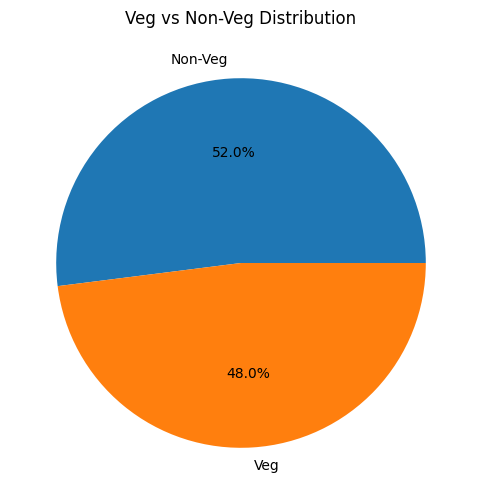


----------------------------------------------------------------------------------------------------
Menu Category Distribution
----------------------------------------------------------------------------------------------------


Sub_Category
Starter            31
Curry              22
Biryani            18
Box Biryani        13
Rice                6
Beverage            4
Seafood Starter     4
Bread               1
Egg                 1
Name: count, dtype: int64

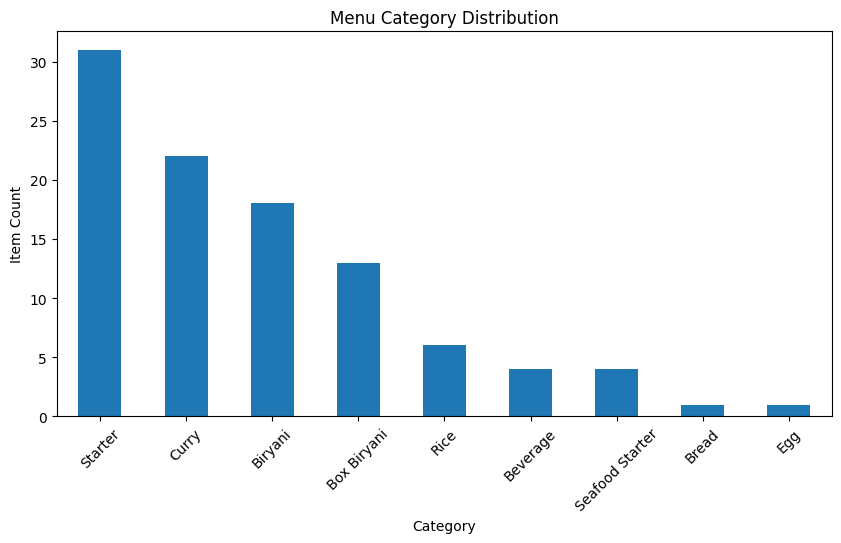


----------------------------------------------------------------------------------------------------
Average Rating by Category
----------------------------------------------------------------------------------------------------


Sub_Category
Beverage           4.625000
Seafood Starter    4.550000
Box Biryani        4.530769
Egg                4.500000
Biryani            4.466667
Rice               4.433333
Curry              4.413636
Starter            4.413333
Bread              4.300000
Name: Rating, dtype: float64

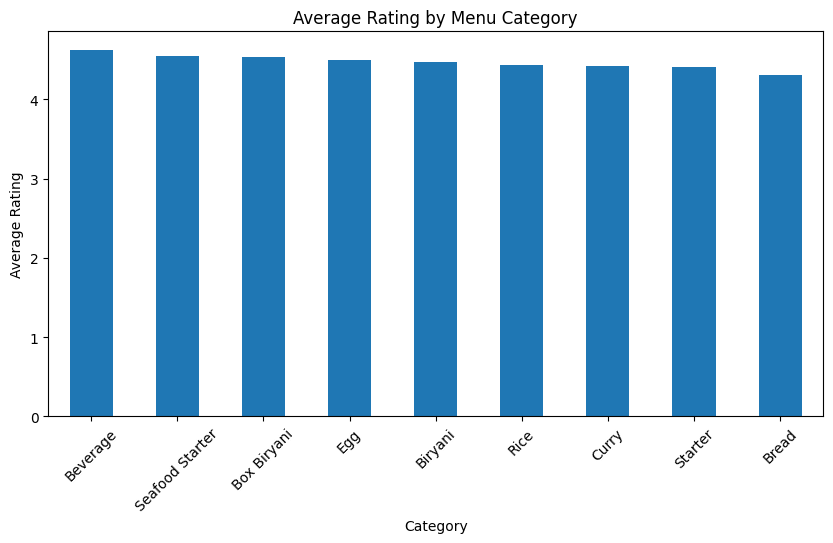


AI Insight:
The menu has a good balance between Veg and Non-Veg items. Starters, curries and biryani dominate the menu. However, customer demand is strongly connected to biryani products, so biryani should remain the main business engine.

BESTSELLER INTELLIGENCE


,Dish_Name,Main_Category,Sub_Category,Rating,Reviews_Clean,Price
49,Chicken Boneless Biryani,Non-Veg,Biryani,4.6,12900.0,375.0
1,Paneer Biryani,Veg,Biryani,4.6,6600.0,380.0
48,Chicken Biryani,Non-Veg,Biryani,4.4,2600.0,365.0
2,Spl Veg Biryani,Veg,Biryani,4.6,2500.0,340.0
3,Mushroom Biryani,Veg,Biryani,4.6,1900.0,380.0
0,Aloo Dum Biryani,Veg,Biryani,4.5,1800.0,330.0
50,Meghana Special Boneless Biryani,Non-Veg,Biryani,4.6,1700.0,383.0
89,Pepper Chicken,Non-Veg,Starter,4.5,1700.0,370.0
84,Meghana Chicken 555,Non-Veg,Starter,4.5,1100.0,375.0
61,Box Meghana Special Boneless Biryani,Non-Veg,Box Biryani,4.5,366.0,270.0


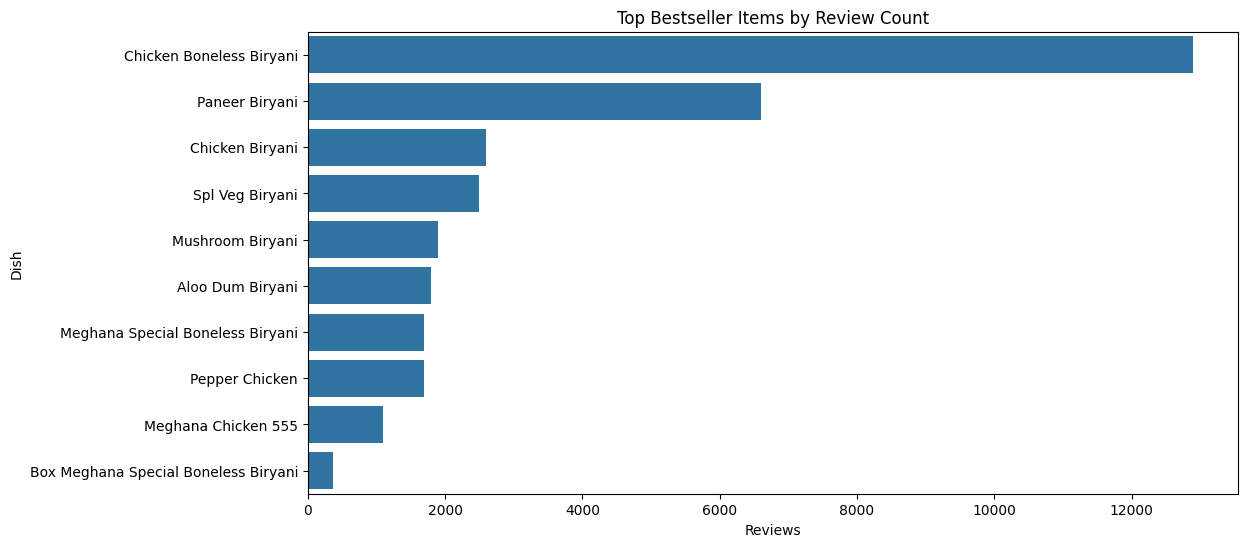


AI Insight:
Bestseller items are already validated by customers. These products should receive the highest visibility on Swiggy, Zomato, Instagram promotions, combo offers and in-store recommendation boards.

HERO PRODUCT STRATEGY


,Dish_Name,Rating,Reviews_Clean,Bestseller,Price,Hero_Score
49,Chicken Boneless Biryani,4.6,12900.0,Yes,375.0,88.800000
1,Paneer Biryani,4.6,6600.0,Yes,380.0,64.381395
2,Spl Veg Biryani,4.6,2500.0,Yes,340.0,48.489922
48,Chicken Biryani,4.4,2600.0,Yes,365.0,47.277519
3,Mushroom Biryani,4.6,1900.0,Yes,380.0,46.164341
50,Meghana Special Boneless Biryani,4.6,1700.0,Yes,383.0,45.389147
0,Aloo Dum Biryani,4.5,1800.0,Yes,330.0,44.976744
89,Pepper Chicken,4.5,1700.0,Yes,370.0,44.589147
84,Meghana Chicken 555,4.5,1100.0,Yes,375.0,42.263566
83,Chicken 65,4.6,1300.0,No,375.0,41.838760



Hero Product:
Chicken Boneless Biryani

Why this is the hero product:
This dish has the strongest combination of rating, review volume, customer validation and bestseller status. It should be treated as the flagship product of the menu.

Action Plan:
1. Pin this item as the first item on Swiggy.
2. Pin this item as the first item on Zomato.
3. Use this item in Instagram reels and YouTube Shorts.
4. Use this item in outdoor advertisements.
5. Position it as Meghana's signature dish.

Expected Impact:
Higher conversion rates, better customer acquisition, stronger brand recall.

MOST LOVED DISHES


,Dish_Name,Rating,Reviews_Clean,Price
49,Chicken Boneless Biryani,4.6,12900.0,375.0
1,Paneer Biryani,4.6,6600.0,380.0
2,Spl Veg Biryani,4.6,2500.0,340.0
3,Mushroom Biryani,4.6,1900.0,380.0
50,Meghana Special Boneless Biryani,4.6,1700.0,383.0
83,Chicken 65,4.6,1300.0,375.0
85,Lemon Chicken,4.6,901.0,375.0
70,Chicken Boneless Curry,4.6,885.0,370.0
54,Prawns Biryani,4.6,640.0,470.0
60,Box Chicken Boneless Biryani,4.6,621.0,265.0


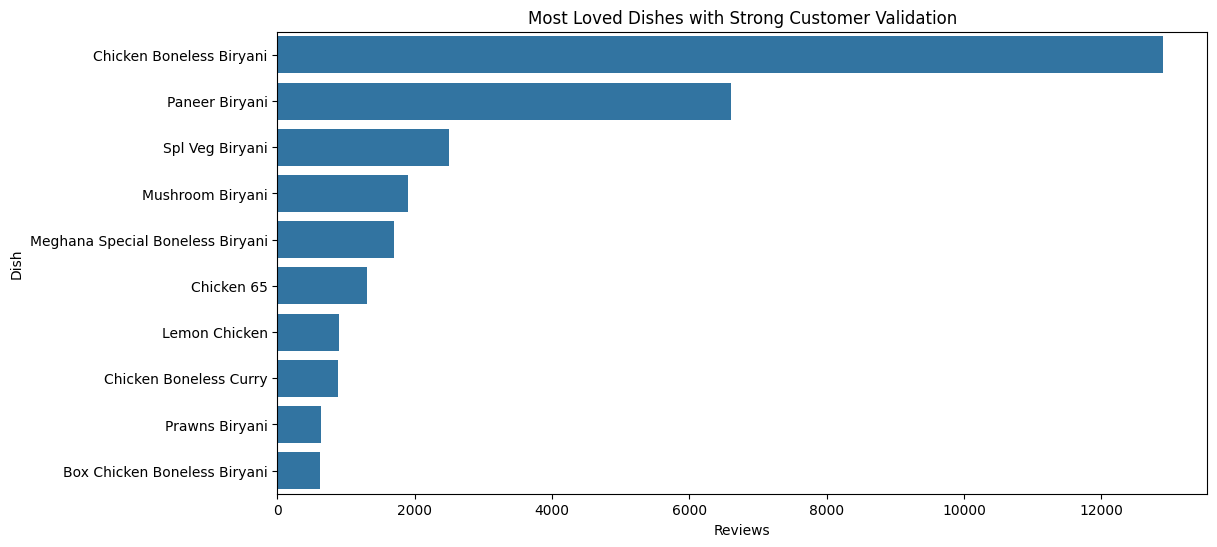


AI Recommendation:
Create premium combos around these dishes. Never discount weak products heavily. Promote winning products because customers have already validated them.

UNDERPERFORMING MENU ANALYSIS


,Dish_Name,Rating,Reviews_Clean,Bestseller,Price,Recommended_Menu_Action
93,Today's Andhra Spl,2.9,21.0,No,410.0,Review or Replace
74,Fish Curry,3.8,42.0,No,425.0,Review or Replace
25,Kaju Masala,3.8,101.0,No,380.0,Review or Replace
75,Prawns Curry,3.9,96.0,No,460.0,Monitor Performance
24,Veg Hyderabadi Curry,4.0,7.0,No,320.0,Monitor Performance
42,Mushroom Kabab,4.0,9.0,No,385.0,Monitor Performance
72,Chicken Curry,4.0,85.0,No,370.0,Monitor Performance
62,Box Chicken Fry Biryani,4.1,7.0,No,270.0,Monitor Performance
5,Veg Manchurian Biryani,4.2,734.0,No,370.0,Monitor Performance
79,Chicken Hyd Curry With Bone,4.3,10.0,No,370.0,Hidden Item - Improve Visibility


Recommended_Menu_Action
High Potential Product              53
Hidden Item - Improve Visibility    21
Star Product                        10
Monitor Performance                  6
Growth Item                          6
Review or Replace                    3
Needs Review                         1
Name: count, dtype: int64

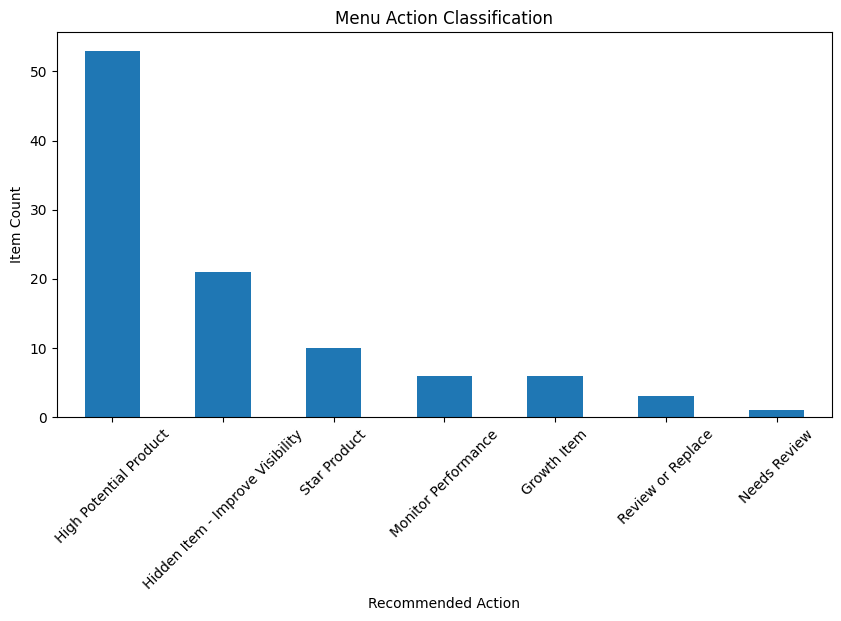


AI Insight:
The menu does not have a widespread quality issue. Most dishes are rated well. However, a few dishes need immediate review, while several hidden items need better visibility.

MENU CLEANUP STRATEGY

----------------------------------------------------------------------------------------------------
Immediate Review or Replace List
----------------------------------------------------------------------------------------------------


,Dish_Name,Rating,Reviews_Clean,Price
25,Kaju Masala,3.8,101.0,380.0
74,Fish Curry,3.8,42.0,425.0
93,Today's Andhra Spl,2.9,21.0,410.0



Action Plan:
Step 1: Collect customer feedback.
Step 2: Review recipe consistency.
Step 3: Compare with competitor dishes.
Step 4: Improve presentation.
Step 5: Retest for 30 days.
Step 6: Remove if ratings do not improve.

----------------------------------------------------------------------------------------------------
Monitor Performance Items
----------------------------------------------------------------------------------------------------


,Dish_Name,Rating,Reviews_Clean,Price
5,Veg Manchurian Biryani,4.2,734.0,370.0
24,Veg Hyderabadi Curry,4.0,7.0,320.0
42,Mushroom Kabab,4.0,9.0,385.0
62,Box Chicken Fry Biryani,4.1,7.0,270.0
72,Chicken Curry,4.0,85.0,370.0
75,Prawns Curry,3.9,96.0,460.0



Action Plan:
These dishes are not failures, but they are not strong enough for aggressive promotion. Monitor them for 60 days before deciding whether to improve, bundle, or reduce visibility.

----------------------------------------------------------------------------------------------------
Hidden Items - Improve Visibility
----------------------------------------------------------------------------------------------------


...


Action Plan:
These dishes are not bad. They have decent ratings but low review volume. Place them in 'Recommended Add-ons', 'People Also Ordered', and combo sections on Swiggy and Zomato to increase visibility.

COMBO INTELLIGENCE


,Dish_Name,Rating,Reviews_Clean,Price
49,Chicken Boneless Biryani,4.6,12900.0,375.0
1,Paneer Biryani,4.6,6600.0,380.0
2,Spl Veg Biryani,4.6,2500.0,340.0
48,Chicken Biryani,4.4,2600.0,365.0
3,Mushroom Biryani,4.6,1900.0,380.0
50,Meghana Special Boneless Biryani,4.6,1700.0,383.0
0,Aloo Dum Biryani,4.5,1800.0,330.0
89,Pepper Chicken,4.5,1700.0,370.0
84,Meghana Chicken 555,4.5,1100.0,375.0
83,Chicken 65,4.6,1300.0,375.0



----------------------------------------------------------------------------------------------------
Family Feast Combo
----------------------------------------------------------------------------------------------------
Chicken Boneless Biryani + Chicken 65 + Soft Drink + Dessert
Target: Families, weekend customers, group orders

----------------------------------------------------------------------------------------------------
Veg Family Combo
----------------------------------------------------------------------------------------------------
Paneer Biryani + Chilly Paneer + Soft Drink + Dessert
Target: Vegetarian families and office groups

----------------------------------------------------------------------------------------------------
Office Lunch Combo
----------------------------------------------------------------------------------------------------
Box Chicken Boneless Biryani (or Introduce Bucket Biriyani) + Soft Drink
Target: IT employees, office workers, students

----

,Dish_Name,Protein_g,Calories,Rating,Price
51,Mutton Biryani,66.69,1586.02,4.3,490.0
50,Meghana Special Boneless Biryani,64.65,1456.21,4.6,383.0
49,Chicken Boneless Biryani,64.22,1446.50,4.6,375.0
48,Chicken Biryani,61.82,1615.27,4.4,365.0
1,Paneer Biryani,61.42,1800.51,4.6,380.0
58,Nati Chicken Biryani,58.94,1606.20,4.5,430.0
56,Chicken Fry Pc Biriyani,55.24,1576.65,4.5,390.0
53,Fish Biriyani,55.02,1429.30,4.4,455.0
29,Chilly Paneer,51.90,871.69,4.6,370.0
89,Pepper Chicken,47.42,609.63,4.5,370.0



AI Recommendation:
1. Launch High Protein Combo.
2. Launch Gym Meal Combo.
3. Launch Low Calorie Meal where possible.
4. Target gym members, office professionals and health-conscious customers.
5. Use nutrition information in app descriptions.

EXPECTED BUSINESS IMPACT
Expected Benefits:
• Higher average order value
• Higher customer acquisition
• Higher repeat customers
• Reduced menu waste
• Higher revenue per customer
• Better brand positioning
• Stronger Swiggy and Zomato presence
• Better offline customer acquisition

CEO PRIORITY ACTION PLAN
Immediate Actions: 0-30 Days
1. Promote hero products.
2. Launch family combos.
3. Fix weak dishes.
4. Improve Swiggy visibility.
5. Improve Zomato visibility.

Medium-Term Actions: 30-90 Days
6. Start driver referral program.
7. Start influencer campaign.
8. Launch corporate lunch combos.
9. Build festival marketing calendar.

Long-Term Actions: 90-180 Days
10. Expand health menu strategy.
11. Launch limited edition creator dishes.
12. Try 

In [33]:
menu_intelligence_report(menu_df)

In [35]:
# ============================================================
# SAVE MENU INTELLIGENCE OUTPUTS
# ============================================================

import os
import pandas as pd
import numpy as np

os.makedirs("outputs", exist_ok=True)

# ============================================================
# CLEAN REVIEWS COLUMN
# ============================================================

menu_df["Reviews_Clean"] = (
    menu_df["Reviews"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

menu_df["Reviews_Clean"] = pd.to_numeric(
    menu_df["Reviews_Clean"],
    errors="coerce"
)

menu_df["Rating"] = pd.to_numeric(
    menu_df["Rating"],
    errors="coerce"
)

# ============================================================
# KPI VALUES
# ============================================================

total_items = len(menu_df)

veg_items = len(
    menu_df[menu_df["Main_Category"] == "Veg"]
)

nonveg_items = len(
    menu_df[menu_df["Main_Category"] == "Non-Veg"]
)

bestseller_items = len(
    menu_df[
        menu_df["Bestseller"]
        .str.upper()
        .eq("YES")
    ]
)

avg_rating = round(
    menu_df["Rating"].mean(),
    2
)

avg_price = round(
    menu_df["Price"].mean(),
    2
)

menu_health_score = round(
    (avg_rating / 5) * 100,
    0
)

# ============================================================
# MENU SUMMARY
# ============================================================

menu_summary = pd.DataFrame({
    "Metric": [
        "Total Menu Items",
        "Veg Items",
        "Non-Veg Items",
        "Bestseller Items",
        "Average Rating",
        "Average Price",
        "Menu Health Score"
    ],
    "Value": [
        total_items,
        veg_items,
        nonveg_items,
        bestseller_items,
        avg_rating,
        avg_price,
        menu_health_score
    ]
})

# ============================================================
# HERO PRODUCTS
# ============================================================

hero_df = menu_df.copy()

hero_df["Rating_Score"] = hero_df["Rating"] * 20

hero_df["Review_Score"] = (
    hero_df["Reviews_Clean"] /
    hero_df["Reviews_Clean"].max()
) * 100

hero_df["Bestseller_Score"] = np.where(
    hero_df["Bestseller"].str.upper() == "YES",
    20,
    0
)

hero_df["Hero_Score"] = (
    hero_df["Rating_Score"] * 0.4
    + hero_df["Review_Score"] * 0.5
    + hero_df["Bestseller_Score"] * 0.1
)

hero_products = (
    hero_df[
        [
            "Dish_Name",
            "Main_Category",
            "Sub_Category",
            "Rating",
            "Reviews_Clean",
            "Bestseller",
            "Price",
            "Hero_Score"
        ]
    ]
    .sort_values(
        "Hero_Score",
        ascending=False
    )
)

# ============================================================
# MOST LOVED DISHES
# ============================================================

most_loved = (
    menu_df[
        [
            "Dish_Name",
            "Main_Category",
            "Sub_Category",
            "Rating",
            "Reviews_Clean",
            "Price"
        ]
    ]
    .query("Reviews_Clean >= 500")
    .sort_values(
        ["Rating", "Reviews_Clean"],
        ascending=False
    )
)

# ============================================================
# MENU CLEANUP CANDIDATES
# ============================================================

def classify_menu_item(row):

    rating = row["Rating"]
    reviews = row["Reviews_Clean"]

    if pd.isna(rating):
        return "Needs Review"

    if rating <= 3.8:
        return "Review or Replace"

    elif rating <= 4.2:
        return "Monitor Performance"

    elif rating <= 4.4:
        if reviews < 500:
            return "Hidden Item - Improve Visibility"
        else:
            return "Growth Item"

    else:
        if reviews >= 1000:
            return "Star Product"
        else:
            return "High Potential Product"


menu_df["Recommended_Menu_Action"] = menu_df.apply(
    classify_menu_item,
    axis=1
)

menu_cleanup_candidates = (
    menu_df[
        [
            "Dish_Name",
            "Main_Category",
            "Sub_Category",
            "Rating",
            "Reviews_Clean",
            "Bestseller",
            "Price",
            "Recommended_Menu_Action"
        ]
    ]
    .sort_values(
        ["Rating", "Reviews_Clean"],
        ascending=[True, True]
    )
)

review_or_replace = menu_cleanup_candidates[
    menu_cleanup_candidates["Recommended_Menu_Action"] == "Review or Replace"
]

hidden_items = menu_cleanup_candidates[
    menu_cleanup_candidates["Recommended_Menu_Action"] == "Hidden Item - Improve Visibility"
]

# ============================================================
# CATEGORY OUTPUTS
# ============================================================

category_dist = (
    menu_df["Sub_Category"]
    .value_counts()
    .reset_index()
)

category_dist.columns = [
    "Sub_Category",
    "Item_Count"
]

category_rating = (
    menu_df
    .groupby("Sub_Category")["Rating"]
    .mean()
    .reset_index()
    .sort_values("Rating", ascending=False)
)

# ============================================================
# SAVE CSV FILES
# ============================================================

menu_summary.to_csv(
    "outputs/Menu_Summary_Output.csv",
    index=False
)

hero_products.to_csv(
    "outputs/Hero_Product_Output.csv",
    index=False
)

most_loved.to_csv(
    "outputs/Most_Loved_Dishes_Output.csv",
    index=False
)

menu_cleanup_candidates.to_csv(
    "outputs/Menu_Cleanup_Output.csv",
    index=False
)

category_dist.to_csv(
    "outputs/Menu_Category_Distribution.csv",
    index=False
)

category_rating.to_csv(
    "outputs/Menu_Category_Rating.csv",
    index=False
)

# ============================================================
# FINAL AI ADVISOR INPUT FILE
# ============================================================

menu_ai_input = pd.DataFrame({
    "Menu_Health_Score": [menu_health_score],
    "Average_Menu_Rating": [avg_rating],
    "Average_Menu_Price": [avg_price],
    "Total_Menu_Items": [total_items],
    "Veg_Items": [veg_items],
    "Non_Veg_Items": [nonveg_items],
    "Bestseller_Items": [bestseller_items],
    "Top_Hero_Products": [
        ", ".join(hero_products.head(5)["Dish_Name"].tolist())
    ],
    "Most_Loved_Dishes": [
        ", ".join(most_loved.head(5)["Dish_Name"].tolist())
    ],
    "Review_Or_Replace_Items": [
        ", ".join(review_or_replace["Dish_Name"].tolist())
    ],
    "Hidden_Items_To_Promote": [
        ", ".join(hidden_items.head(10)["Dish_Name"].tolist())
    ],
    "Menu_Strategy_Reference": [
        "Promote hero biryani products, build combos, improve weak dishes, increase Swiggy/Zomato visibility, and use driver/influencer/festival campaigns for customer acquisition."
    ]
})

menu_ai_input.to_csv(
    "outputs/Menu_AI_Advisor_Input.csv",
    index=False
)

print("="*70)
print("MENU INTELLIGENCE OUTPUTS SAVED SUCCESSFULLY")
print("="*70)

print("Saved inside outputs folder:")
print("1. Menu_Summary_Output.csv")
print("2. Hero_Product_Output.csv")
print("3. Most_Loved_Dishes_Output.csv")
print("4. Menu_Cleanup_Output.csv")
print("5. Menu_Category_Distribution.csv")
print("6. Menu_Category_Rating.csv")
print("7. Menu_AI_Advisor_Input.csv")

MENU INTELLIGENCE OUTPUTS SAVED SUCCESSFULLY
Saved inside outputs folder:
1. Menu_Summary_Output.csv
2. Hero_Product_Output.csv
3. Most_Loved_Dishes_Output.csv
4. Menu_Cleanup_Output.csv
5. Menu_Category_Distribution.csv
6. Menu_Category_Rating.csv
7. Menu_AI_Advisor_Input.csv
